<a href="https://colab.research.google.com/github/mafedcp65-netizen/Revision-de-la-literatura/blob/main/Graphs_Review_English.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# @title Setup: imports and JAMA-style visual theme
# This notebook uses only embedded aggregate values. It does not read or upload any external dataset.

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("wordcloud") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "wordcloud"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from matplotlib.ticker import MaxNLocator
from IPython.display import display

# JAMA-like palette: restrained, publication-oriented, and clean.
JAMA_BLUE = "#4C78A8"
JAMA_RED = "#C44E52"
JAMA_TEAL = "#72B7B2"
JAMA_GOLD = "#D4A24C"
JAMA_GREEN = "#55A868"
JAMA_PURPLE = "#8172B3"
JAMA_GRAY = "#8C8C8C"
JAMA_LIGHT_GRAY = "#E6E6E6"
JAMA_MID_GRAY = "#BDBDBD"
JAMA_DARK = "#222222"

GREEN_IMAGE = JAMA_BLUE
BLUE_IMAGE = JAMA_TEAL

JAMA_PALETTE = [
    JAMA_BLUE, JAMA_RED, JAMA_TEAL, JAMA_GOLD, JAMA_GREEN,
    JAMA_PURPLE, JAMA_GRAY, "#6C8EBF", "#A0CBE8", "#B07AA1"
]

PASTELS = JAMA_PALETTE

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelcolor": JAMA_DARK,
    "axes.edgecolor": JAMA_DARK,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.color": JAMA_DARK,
    "ytick.color": JAMA_DARK,
    "text.color": JAMA_DARK,
    "grid.color": JAMA_LIGHT_GRAY,
    "grid.linewidth": 0.7,
    "grid.alpha": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
})


In [ ]:

# @title Embedded aggregate data and JAMA-style plotting helpers
# All labels, column names, axis names, and printed outputs are in English.

journal_frequency = pd.DataFrame({
    "Journal": [
        "jco clinical cancer informatics",
        "artificial intelligence in medicine",
        "journal of biomedical informatics",
        "frontiers in digital health",
        "journal of the american medical informatics association",
        "international journal of medical informatics",
        "ieee journal of biomedical and health informatics",
        "plos one",
        "amia annual symposium proceedings",
        "studies in health technology and informatics",
    ],
    "Frequency": [10, 3, 3, 2, 2, 2, 2, 2, 2, 2]
})

analytical_task_frequency = pd.DataFrame({
    "Analytical task": [
        "text classification",
        "named entity recognition (NER)",
        "concept normalization",
        "information retrieval",
        "relation extraction (RE)",
        "other tasks",
        "question answering (QA)",
    ],
    "Frequency": [39, 23, 14, 10, 6, 2, 1]
})

algorithm_frequency = pd.DataFrame({
    "Algorithm": [
        "support vector machine (SVM)",
        "rule-based",
        "transformers",
        "word embeddings",
        "regular expressions",
        "decision trees",
        "naive Bayes (NB)",
        "logistic regression",
        "conditional random fields (CRF)",
        "TF-IDF",
        "random forest (RF)",
        "convolutional neural networks (CNN)",
    ],
    "Frequency": [13, 13, 10, 9, 9, 6, 6, 5, 5, 5, 5, 4]
})

application_frequency = pd.DataFrame({
    "Application": ["custom pipeline", "other", "GATE", "cTAKES"],
    "Frequency": [42, 7, 2, 2]
})

approach_frequency = pd.DataFrame({
    "Approach": ["multi-task analytical approach", "single task"],
    "Frequency": [28, 20]
})

cancer_site_frequency = pd.DataFrame({
    "Cancer site": ["all sites as topography", "solid tumors only"],
    "Frequency": [26, 22]
})

document_type_frequency = pd.DataFrame({
    "Document type": [
        "pathology report",
        "clinical notes",
        "imaging report",
        "administrative or insurance data",
        "death certificate",
        "laboratory reports",
        "mandatory notification systems",
        "autopsies",
    ],
    "Frequency": [39, 8, 4, 3, 2, 2, 2, 1]
})

registry_process_frequency = pd.DataFrame({
    "Registry process": [
        "key element extraction",
        "identification of whether a report mentions cancer",
        "identification of recurrence or metastasis",
        "biomarker information extraction",
        "identification of case origin",
        "follow-up",
        "other",
        "identification of reportable cases",
        "information retrieval",
        "identification of multiple primaries",
    ],
    "Frequency": [33, 20, 6, 5, 4, 3, 3, 2, 1, 1]
})

clinical_prediction_frequency = pd.DataFrame({
    "Clinical prediction": ["classification", "regression"],
    "Frequency": [47, 1]
})


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", which="major", length=4, width=0.8, color=JAMA_DARK)
    ax.set_axisbelow(True)


def plot_horizontal_bar(data, category_column, value_column, title, color, x_label="Frequency", y_label=""):
    if data.empty:
        print(f"No data available for: {title}")
        return

    height = max(4, 0.5 * len(data) + 1.5)
    fig, ax = plt.subplots(figsize=(9.25, height), dpi=130)
    bars = ax.barh(
        data[category_column],
        data[value_column],
        color=color,
        edgecolor=JAMA_DARK,
        linewidth=0.6
    )

    ax.set_title(title, loc="left", pad=10)
    ax.set_xlabel(x_label)
    if y_label:
        ax.set_ylabel(y_label)

    ax.grid(axis="x", linestyle="-", linewidth=0.7)
    ax.set_xlim(0, data[value_column].max() * 1.12)
    ax.invert_yaxis()
    style_axis(ax)

    offset = data[value_column].max() * 0.012
    for bar, value in zip(bars, data[value_column]):
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            str(int(value)),
            va="center",
            ha="left",
            fontsize=10,
            color=JAMA_DARK
        )

    plt.tight_layout()
    plt.show()

print("Data source: embedded aggregate values")
print("Missing columns: none")
print("Analyzed records: 48")


Data source: embedded aggregate values
Missing columns: none
Analyzed records: 48


## Bar charts


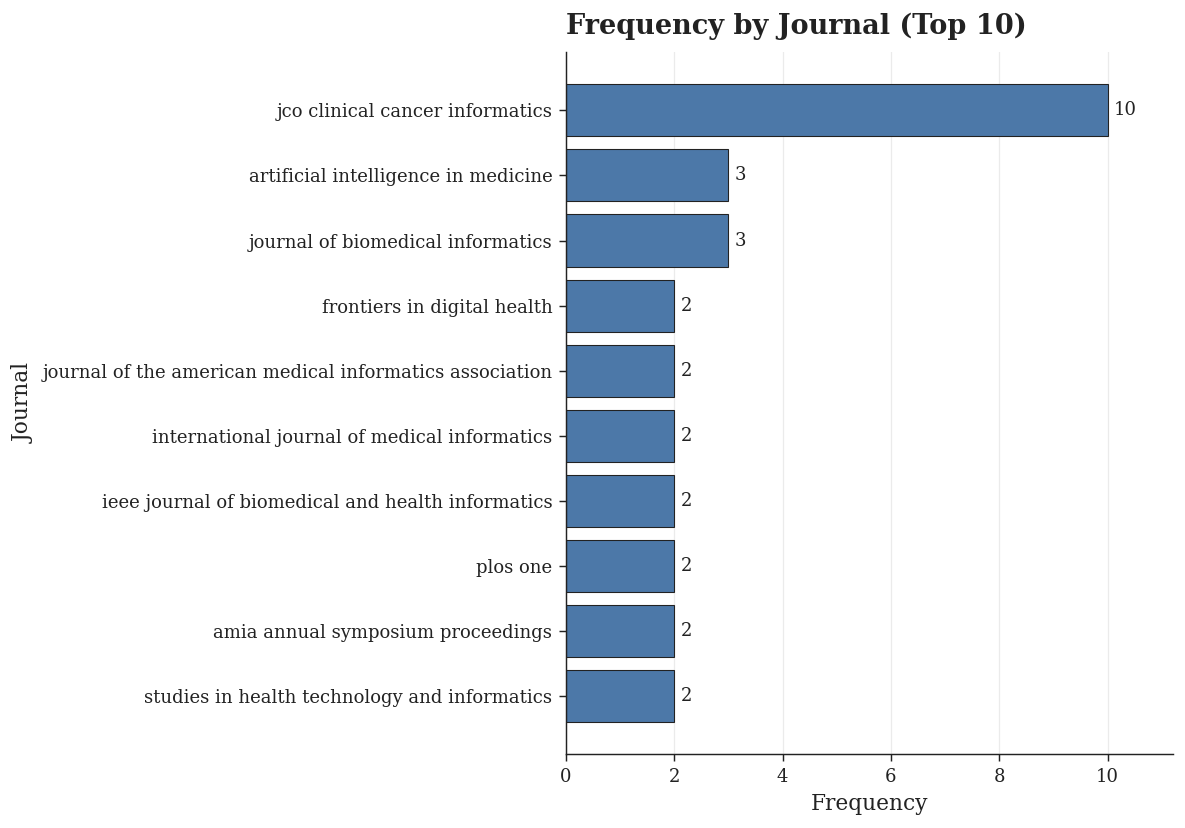

In [ ]:
# @title Journal frequency
plot_horizontal_bar(
    journal_frequency,
    category_column="Journal",
    value_column="Frequency",
    title="Frequency by Journal (Top 10)",
    color=PASTELS[0],
    y_label="Journal"
)


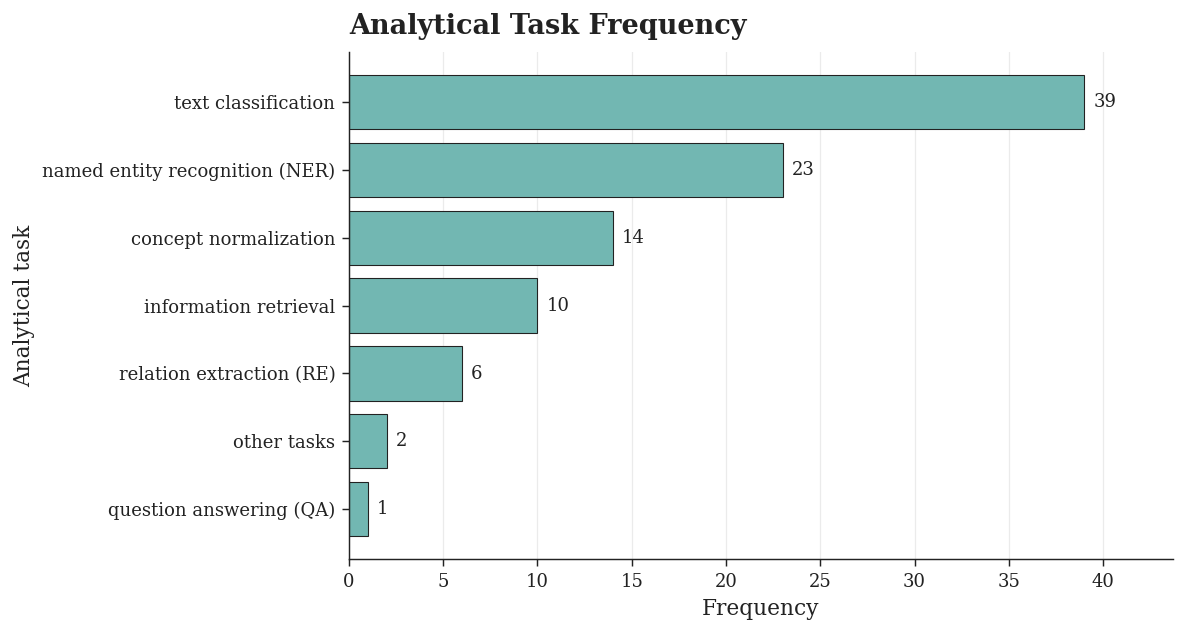

In [ ]:
# @title Analytical task frequency
plot_horizontal_bar(
    analytical_task_frequency,
    category_column="Analytical task",
    value_column="Frequency",
    title="Analytical Task Frequency",
    color=PASTELS[2],
    y_label="Analytical task"
)


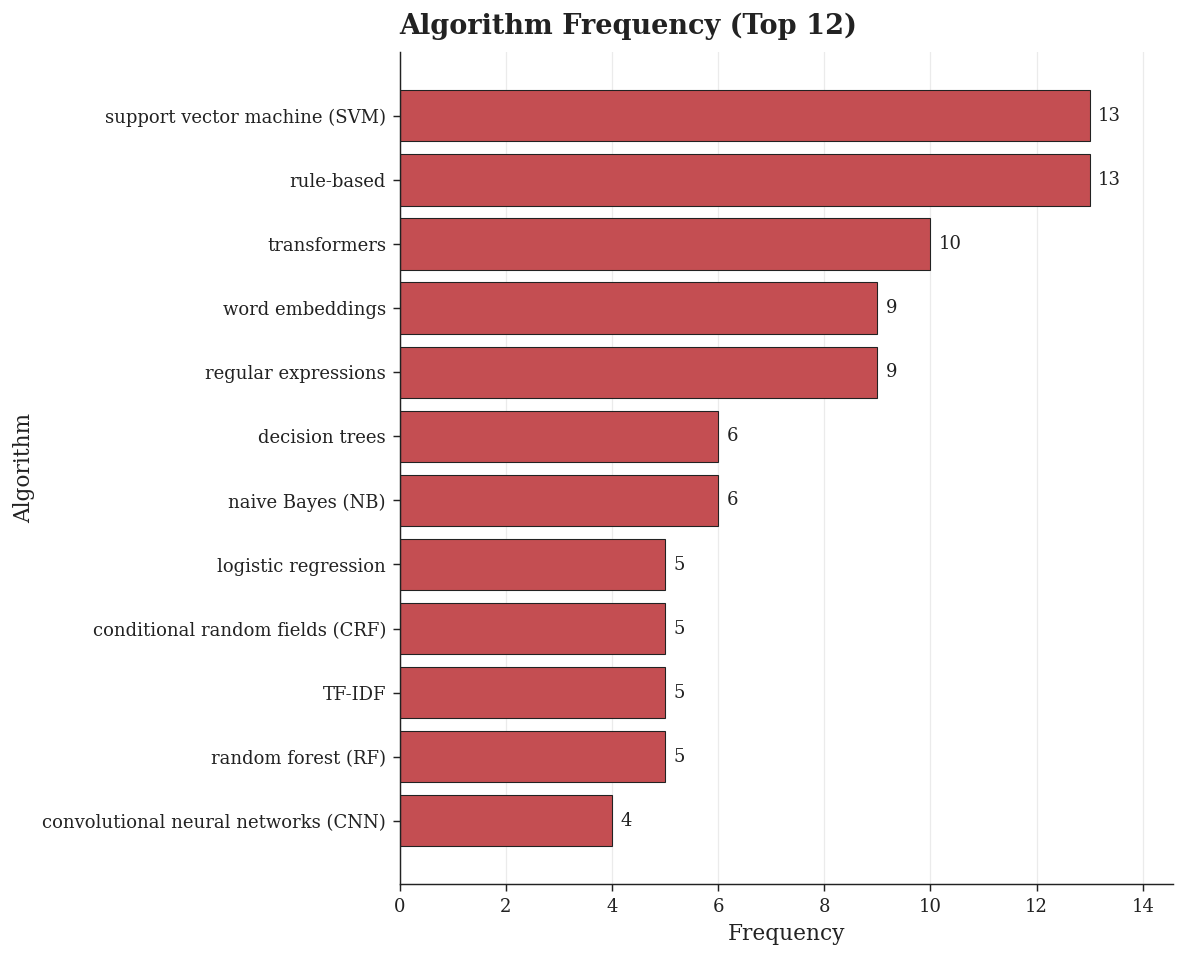

In [ ]:
# @title Algorithm frequency
plot_horizontal_bar(
    algorithm_frequency,
    category_column="Algorithm",
    value_column="Frequency",
    title="Algorithm Frequency (Top 12)",
    color=PASTELS[1],
    y_label="Algorithm"
)


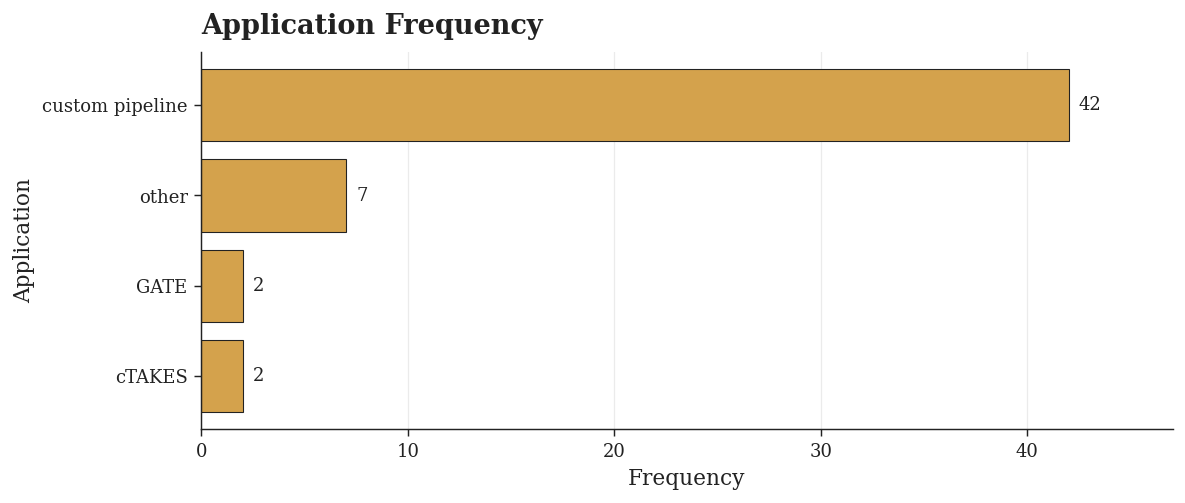

In [ ]:
# @title Application frequency
plot_horizontal_bar(
    application_frequency,
    category_column="Application",
    value_column="Frequency",
    title="Application Frequency",
    color=PASTELS[3],
    y_label="Application"
)


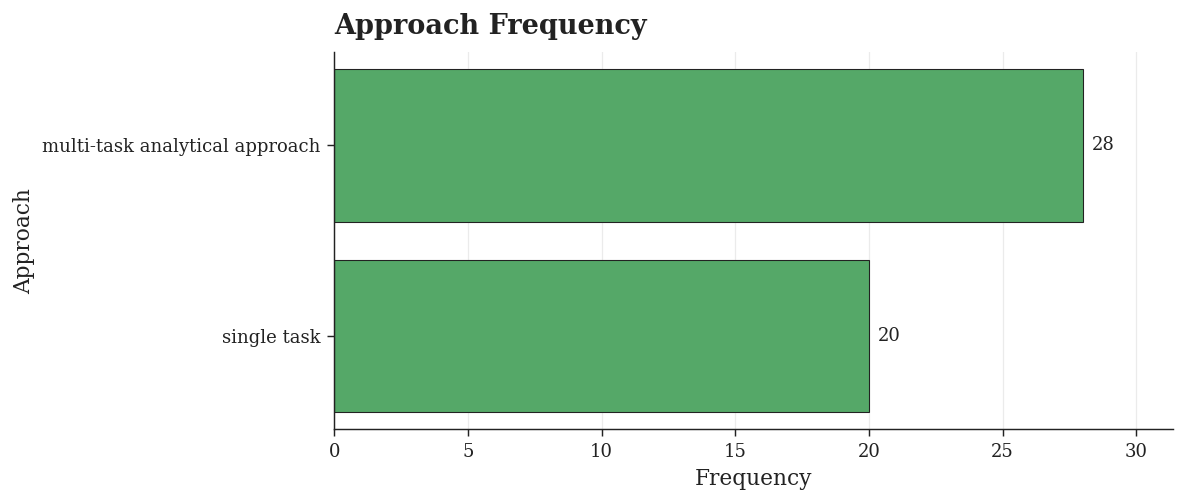

In [ ]:
# @title Approach frequency
plot_horizontal_bar(
    approach_frequency,
    category_column="Approach",
    value_column="Frequency",
    title="Approach Frequency",
    color=PASTELS[4],
    y_label="Approach"
)


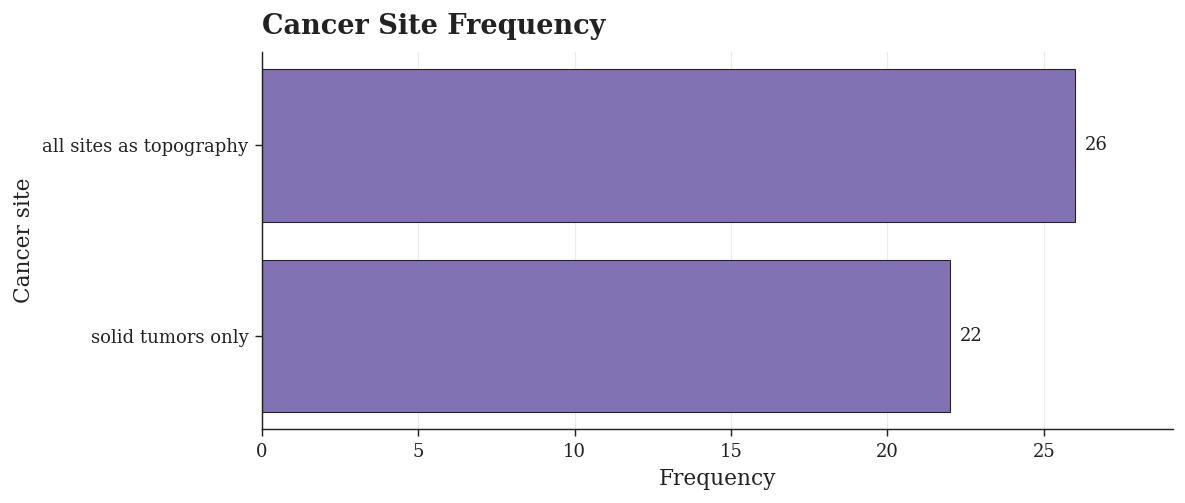

In [ ]:
# @title Cancer site frequency
plot_horizontal_bar(
    cancer_site_frequency,
    category_column="Cancer site",
    value_column="Frequency",
    title="Cancer Site Frequency",
    color=PASTELS[5],
    y_label="Cancer site"
)


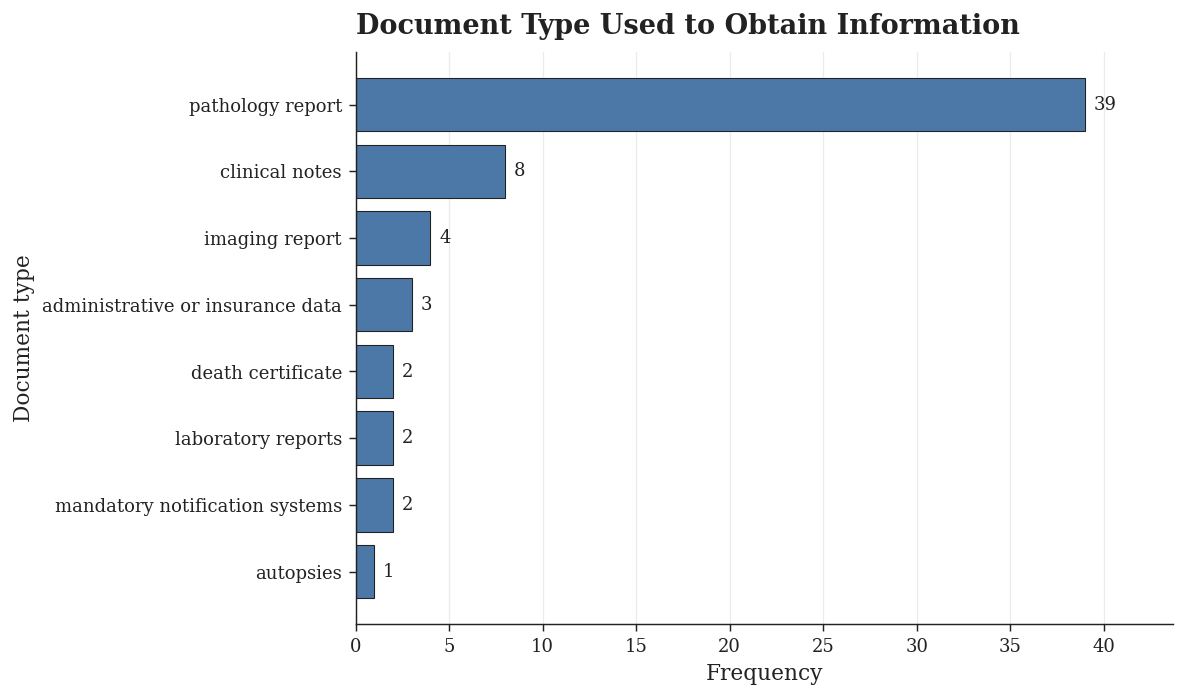

In [ ]:
# @title Document type frequency
plot_horizontal_bar(
    document_type_frequency,
    category_column="Document type",
    value_column="Frequency",
    title="Document Type Used to Obtain Information",
    color=GREEN_IMAGE,
    y_label="Document type"
)


Registry process frequency:
Registry process
key element extraction                                33
identification of whether a report mentions cancer    20
identification of recurrence or metastasis             6
biomarker information extraction                       5
identification of case origin                          4
follow-up                                              3
other                                                  3
identification of reportable cases                     2
information retrieval                                  1
identification of multiple primaries                   1


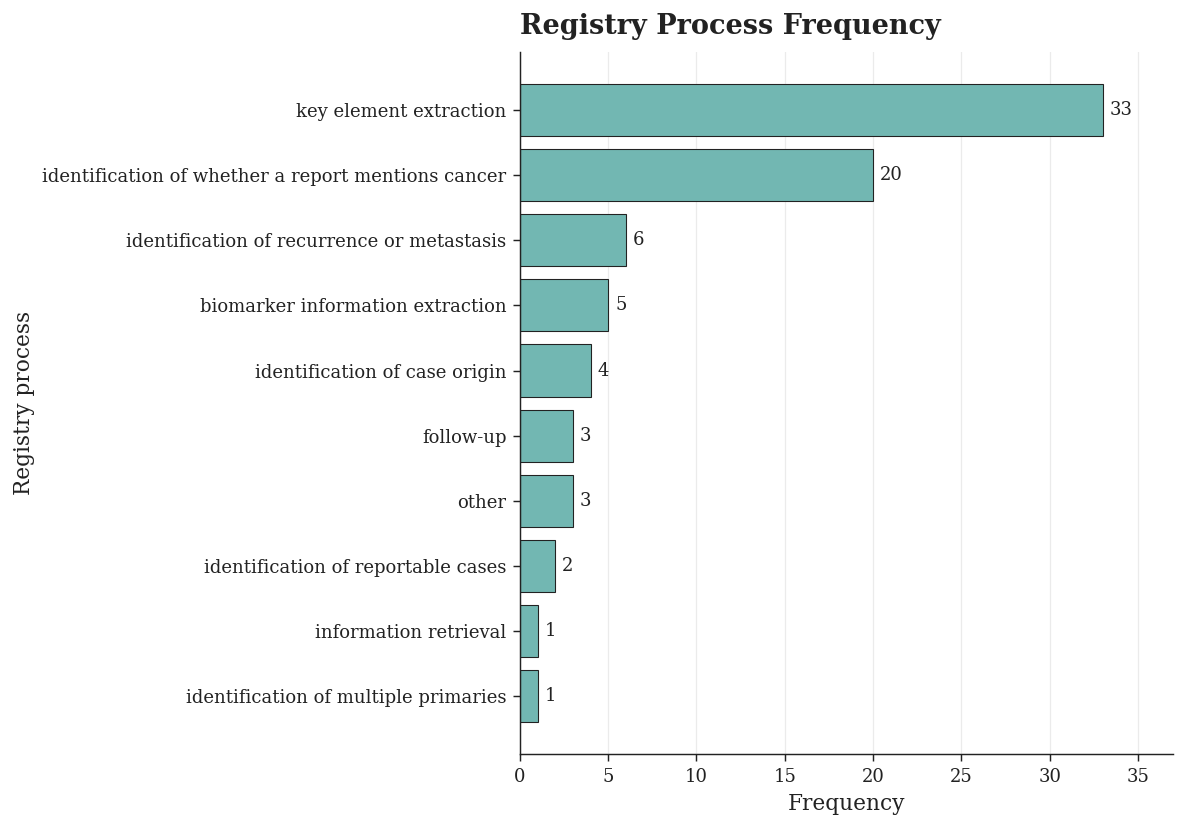

In [ ]:
# @title Registry process frequency
print("Registry process frequency:")
print(registry_process_frequency.set_index("Registry process")["Frequency"].to_string())

plot_horizontal_bar(
    registry_process_frequency,
    category_column="Registry process",
    value_column="Frequency",
    title="Registry Process Frequency",
    color=BLUE_IMAGE,
    y_label="Registry process"
)


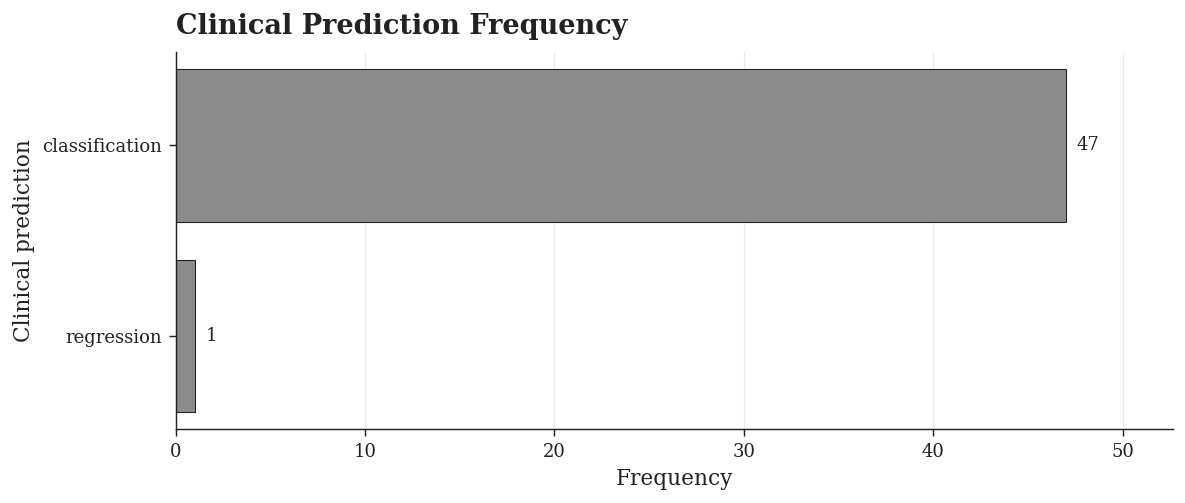

In [ ]:
# @title Clinical prediction frequency
plot_horizontal_bar(
    clinical_prediction_frequency,
    category_column="Clinical prediction",
    value_column="Frequency",
    title="Clinical Prediction Frequency",
    color=PASTELS[6],
    y_label="Clinical prediction"
)


## Word cloud and boxplot


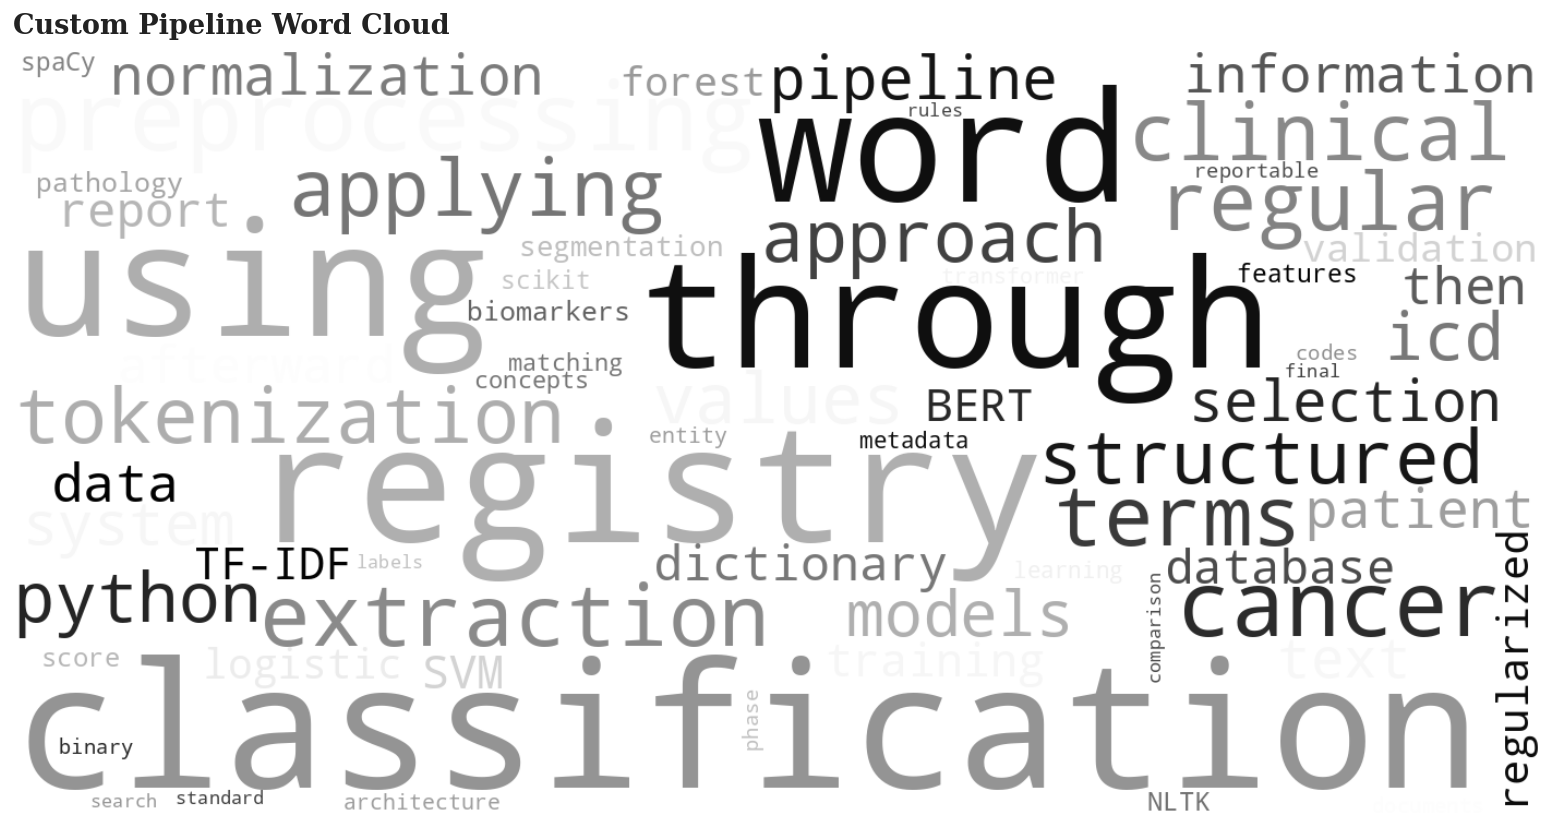

In [ ]:

# @title Custom pipeline word cloud
word_frequencies = {
    "classification": 120,
    "registry": 105,
    "using": 98,
    "word": 92,
    "through": 88,
    "preprocessing": 72,
    "cancer": 66,
    "extraction": 58,
    "terms": 55,
    "regular": 52,
    "clinical": 50,
    "applying": 48,
    "tokenization": 45,
    "structured": 43,
    "approach": 41,
    "values": 39,
    "python": 38,
    "icd": 36,
    "features": 34,
    "models": 33,
    "pipeline": 30,
    "system": 29,
    "selection": 28,
    "normalization": 27,
    "text": 27,
    "patient": 26,
    "information": 25,
    "data": 25,
    "then": 24,
    "afterward": 23,
    "dictionary": 22,
    "database": 21,
    "report": 21,
    "training": 20,
    "SVM": 20,
    "BERT": 19,
    "TF-IDF": 18,
    "regularized": 17,
    "logistic": 16,
    "forest": 15,
    "validation": 14,
    "segmentation": 13,
    "biomarkers": 12,
    "pathology": 12,
    "documents": 12,
    "score": 11,
    "NLTK": 11,
    "scikit": 10,
    "spaCy": 10,
    "features": 10,
    "matching": 9,
    "concepts": 9,
    "metadata": 8,
    "learning": 8,
    "architecture": 7,
    "transformer": 7,
    "entity": 7,
    "phase": 6,
    "reportable": 6,
    "binary": 6,
    "documents": 6,
    "codes": 6,
    "comparison": 5,
    "search": 5,
    "final": 5,
    "standard": 5,
    "labels": 5,
    "rules": 5,
}

stopwords = STOPWORDS.union({"model", "data", "text", "report", "reports", "use", "using"})

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Greys",
    stopwords=stopwords,
    collocations=False,
    random_state=7,
    contour_width=0
).generate_from_frequencies(word_frequencies)

plt.figure(figsize=(13.5, 6.5), dpi=130)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Custom Pipeline Word Cloud", loc="left", pad=10)
plt.tight_layout()
plt.show()


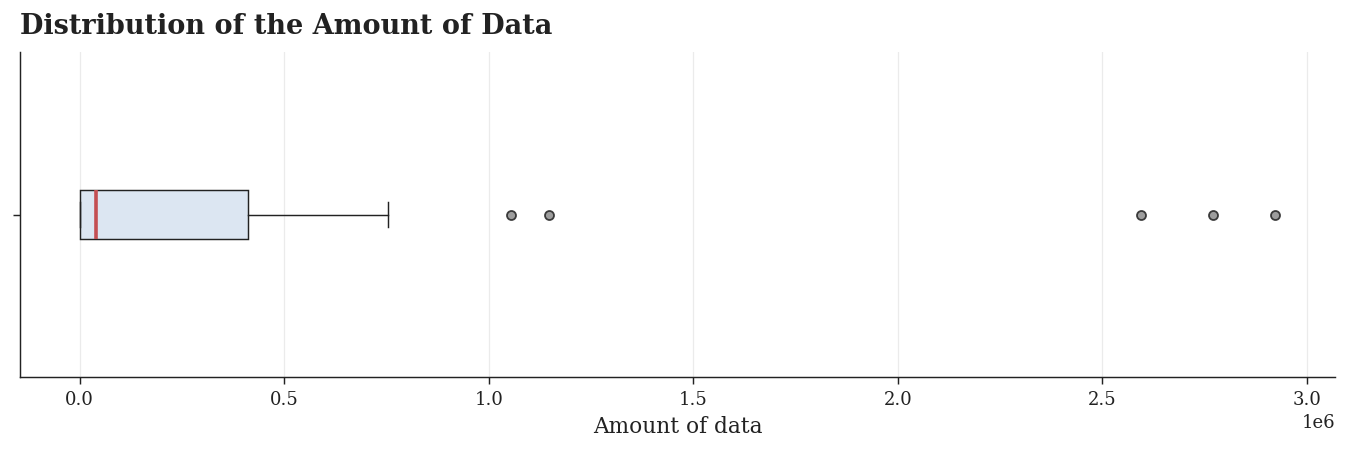

Numeric summary:
count         47.0
mean      338836.8
std       700563.6
min          457.0
25%         1502.5
50%        40000.0
75%       411117.5
max      2923291.0
Name: amount of data entered into the model, dtype: float64


In [ ]:

# @title Data volume distribution
boxplot_stats = [{
    "label": "",
    "whislo": 457,
    "q1": 1502.5,
    "med": 40000,
    "q3": 411117.5,
    "whishi": 754000,
    "fliers": [1054000, 1147000, 2596000, 2772000, 2923291]
}]

numeric_summary = pd.Series({
    "count": 47.0,
    "mean": 338836.8,
    "std": 700563.6,
    "min": 457.0,
    "25%": 1502.5,
    "50%": 40000.0,
    "75%": 411117.5,
    "max": 2923291.0,
}, name="amount of data entered into the model")

fig, ax = plt.subplots(figsize=(10.5, 3.6), dpi=130)
ax.bxp(
    boxplot_stats,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#DCE6F2", edgecolor=JAMA_DARK, linewidth=0.8),
    medianprops=dict(color=JAMA_RED, linewidth=2.0),
    whiskerprops=dict(color=JAMA_DARK, linewidth=0.8),
    capprops=dict(color=JAMA_DARK, linewidth=0.8),
    flierprops=dict(marker="o", markerfacecolor=JAMA_GRAY, markeredgecolor=JAMA_DARK, alpha=0.85, markersize=5)
)

ax.set_title("Distribution of the Amount of Data", loc="left", pad=10)
ax.set_xlabel("Amount of data")
ax.grid(axis="x", linestyle="-", linewidth=0.7)
style_axis(ax)
plt.tight_layout()
plt.show()

print("Numeric summary:")
print(numeric_summary)


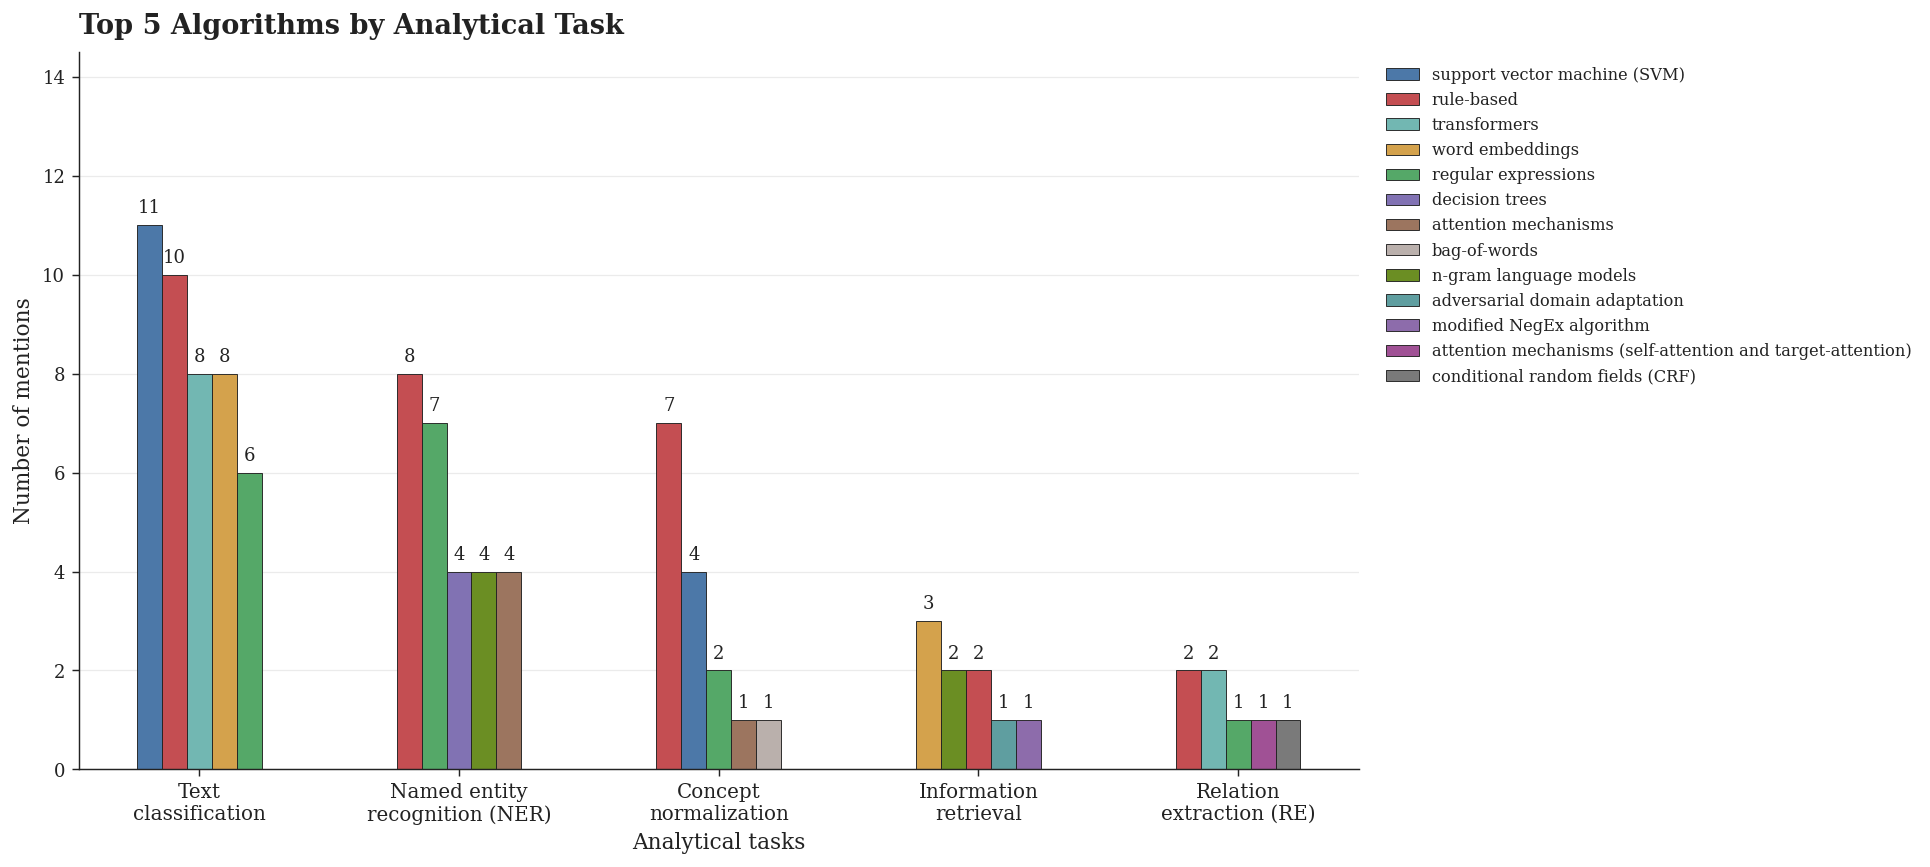

In [ ]:

# @title Top 5 algorithms by analytical task
top_algorithms_by_task = {
    "Text classification": [
        ("support vector machine (SVM)", 11),
        ("rule-based", 10),
        ("transformers", 8),
        ("word embeddings", 8),
        ("regular expressions", 6),
    ],
    "Named entity recognition (NER)": [
        ("rule-based", 8),
        ("regular expressions", 7),
        ("decision trees", 4),
        ("n-gram language models", 4),
        ("attention mechanisms", 4),
    ],
    "Concept normalization": [
        ("rule-based", 7),
        ("support vector machine (SVM)", 4),
        ("regular expressions", 2),
        ("attention mechanisms", 1),
        ("bag-of-words", 1),
    ],
    "Information retrieval": [
        ("word embeddings", 3),
        ("n-gram language models", 2),
        ("rule-based", 2),
        ("adversarial domain adaptation", 1),
        ("modified NegEx algorithm", 1),
    ],
    "Relation extraction (RE)": [
        ("rule-based", 2),
        ("transformers", 2),
        ("regular expressions", 1),
        ("attention mechanisms (self-attention and target-attention)", 1),
        ("conditional random fields (CRF)", 1),
    ],
}

task_order = list(top_algorithms_by_task.keys())

categorical_palette = [
    JAMA_BLUE, JAMA_RED, JAMA_TEAL, JAMA_GOLD, JAMA_GREEN,
    JAMA_PURPLE, "#9C755F", "#BAB0AC", "#6B8E23", "#5F9EA0",
    "#8D6CAB", "#A05195", "#7A7A7A"
]

unique_algorithms = [
    "support vector machine (SVM)",
    "rule-based",
    "transformers",
    "word embeddings",
    "regular expressions",
    "decision trees",
    "attention mechanisms",
    "bag-of-words",
    "n-gram language models",
    "adversarial domain adaptation",
    "modified NegEx algorithm",
    "attention mechanisms (self-attention and target-attention)",
    "conditional random fields (CRF)",
]

color_map = {algorithm: categorical_palette[i % len(categorical_palette)] for i, algorithm in enumerate(unique_algorithms)}

fig, ax = plt.subplots(figsize=(15, 6.8), dpi=130)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

group_centers = np.arange(len(task_order)) * 2.5
bar_width = 0.24
legend_handles = {}

for i, task in enumerate(task_order):
    pairs = top_algorithms_by_task[task]
    offsets = np.linspace(-(len(pairs) - 1) / 2 * bar_width, (len(pairs) - 1) / 2 * bar_width, len(pairs))

    for offset, (algorithm, value) in zip(offsets, pairs):
        x = group_centers[i] + offset
        color = color_map[algorithm]
        bar = ax.bar(x, value, width=bar_width, color=color, edgecolor=JAMA_DARK, linewidth=0.5)
        ax.text(x, value + 0.16, str(value), ha="center", va="bottom", fontsize=10, color=JAMA_DARK)
        if algorithm not in legend_handles:
            legend_handles[algorithm] = bar[0]

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [
        "Text\nclassification",
        "Named entity\nrecognition (NER)",
        "Concept\nnormalization",
        "Information\nretrieval",
        "Relation\nextraction (RE)",
    ],
    fontsize=11
)

ax.set_ylabel("Number of mentions")
ax.set_xlabel("Analytical tasks")
ax.set_title("Top 5 Algorithms by Analytical Task", loc="left", pad=10)

ax.tick_params(axis="y", labelsize=10)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.grid(True, linestyle="-", linewidth=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0, max(value for pairs in top_algorithms_by_task.values() for _, value in pairs) + 3.5)
style_axis(ax)

ax.legend(
    [legend_handles[algorithm] for algorithm in unique_algorithms],
    unique_algorithms,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    fontsize=9,
    title=None
)

plt.tight_layout()
plt.show()


Count by registry process and analytical task:


,Text classification,Named entity recognition (NER),Concept normalization,Information retrieval,Relation extraction (RE),Other tasks
Registry process,,,,,,
Key element extraction,26,17,11,5,5,19
Identification of whether a report\nmentions cancer,20,9,10,5,2,8
Identification of recurrence\nor metastasis,6,3,3,2,1,2
Other registry processes,17,9,9,5,6,9


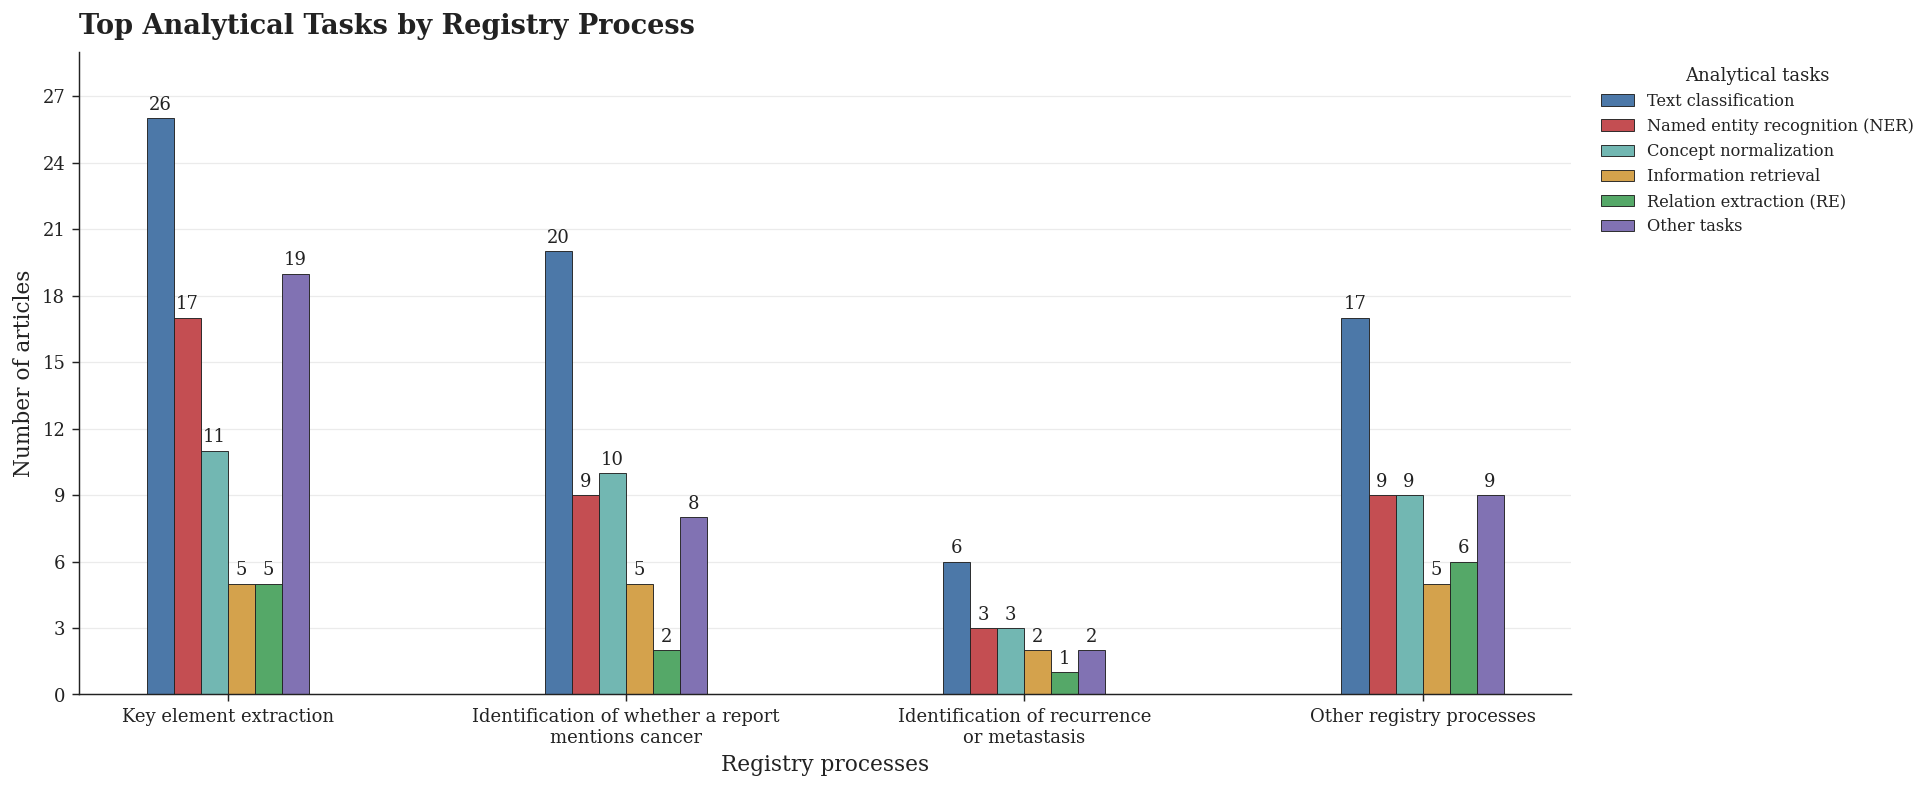

In [ ]:

# @title Top analytical tasks by registry process
process_task_table = pd.DataFrame(
    {
        "Text classification": [26, 20, 6, 17],
        "Named entity recognition (NER)": [17, 9, 3, 9],
        "Concept normalization": [11, 10, 3, 9],
        "Information retrieval": [5, 5, 2, 5],
        "Relation extraction (RE)": [5, 2, 1, 6],
        "Other tasks": [19, 8, 2, 9],
    },
    index=[
        "Key element extraction",
        "Identification of whether a report\nmentions cancer",
        "Identification of recurrence\nor metastasis",
        "Other registry processes",
    ]
)
process_task_table.index.name = "Registry process"

print("Count by registry process and analytical task:")
display(process_task_table)

jama_task_colors = {
    "Text classification": JAMA_BLUE,
    "Named entity recognition (NER)": JAMA_RED,
    "Concept normalization": JAMA_TEAL,
    "Information retrieval": JAMA_GOLD,
    "Relation extraction (RE)": JAMA_GREEN,
    "Other tasks": JAMA_PURPLE,
}

fig, ax = plt.subplots(figsize=(15, 6.2), dpi=130)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

process_order = list(process_task_table.index)
task_order = list(process_task_table.columns)

group_centers = np.arange(len(process_order)) * 2.8
bar_width = 0.19

for i, task in enumerate(task_order):
    values = process_task_table[task].values
    x_positions = group_centers + (i - (len(task_order) - 1) / 2) * bar_width
    bars = ax.bar(
        x_positions,
        values,
        width=bar_width,
        color=jama_task_colors[task],
        edgecolor=JAMA_DARK,
        linewidth=0.5,
        label=task
    )
    for x, value in zip(x_positions, values):
        if value > 0:
            ax.text(x, value + 0.2, str(int(value)), ha="center", va="bottom", fontsize=10, color=JAMA_DARK)

ax.set_xticks(group_centers)
ax.set_xticklabels(process_order, fontsize=10)
ax.set_ylabel("Number of articles")
ax.set_xlabel("Registry processes")
ax.set_title("Top Analytical Tasks by Registry Process", loc="left", pad=10)
ax.tick_params(axis="y", labelsize=10)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.grid(True, linestyle="-", linewidth=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0, process_task_table.values.max() + 3)
style_axis(ax)

ax.legend(
    title="Analytical tasks",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()


## Map


,Country,Frequency
0,United States,22
1,Australia,4
2,Italy,3
3,Colombia,3
4,Canada,3
5,Chile,2
6,Taiwan,2
7,South Africa,2
8,Brazil,1
9,Germany,1


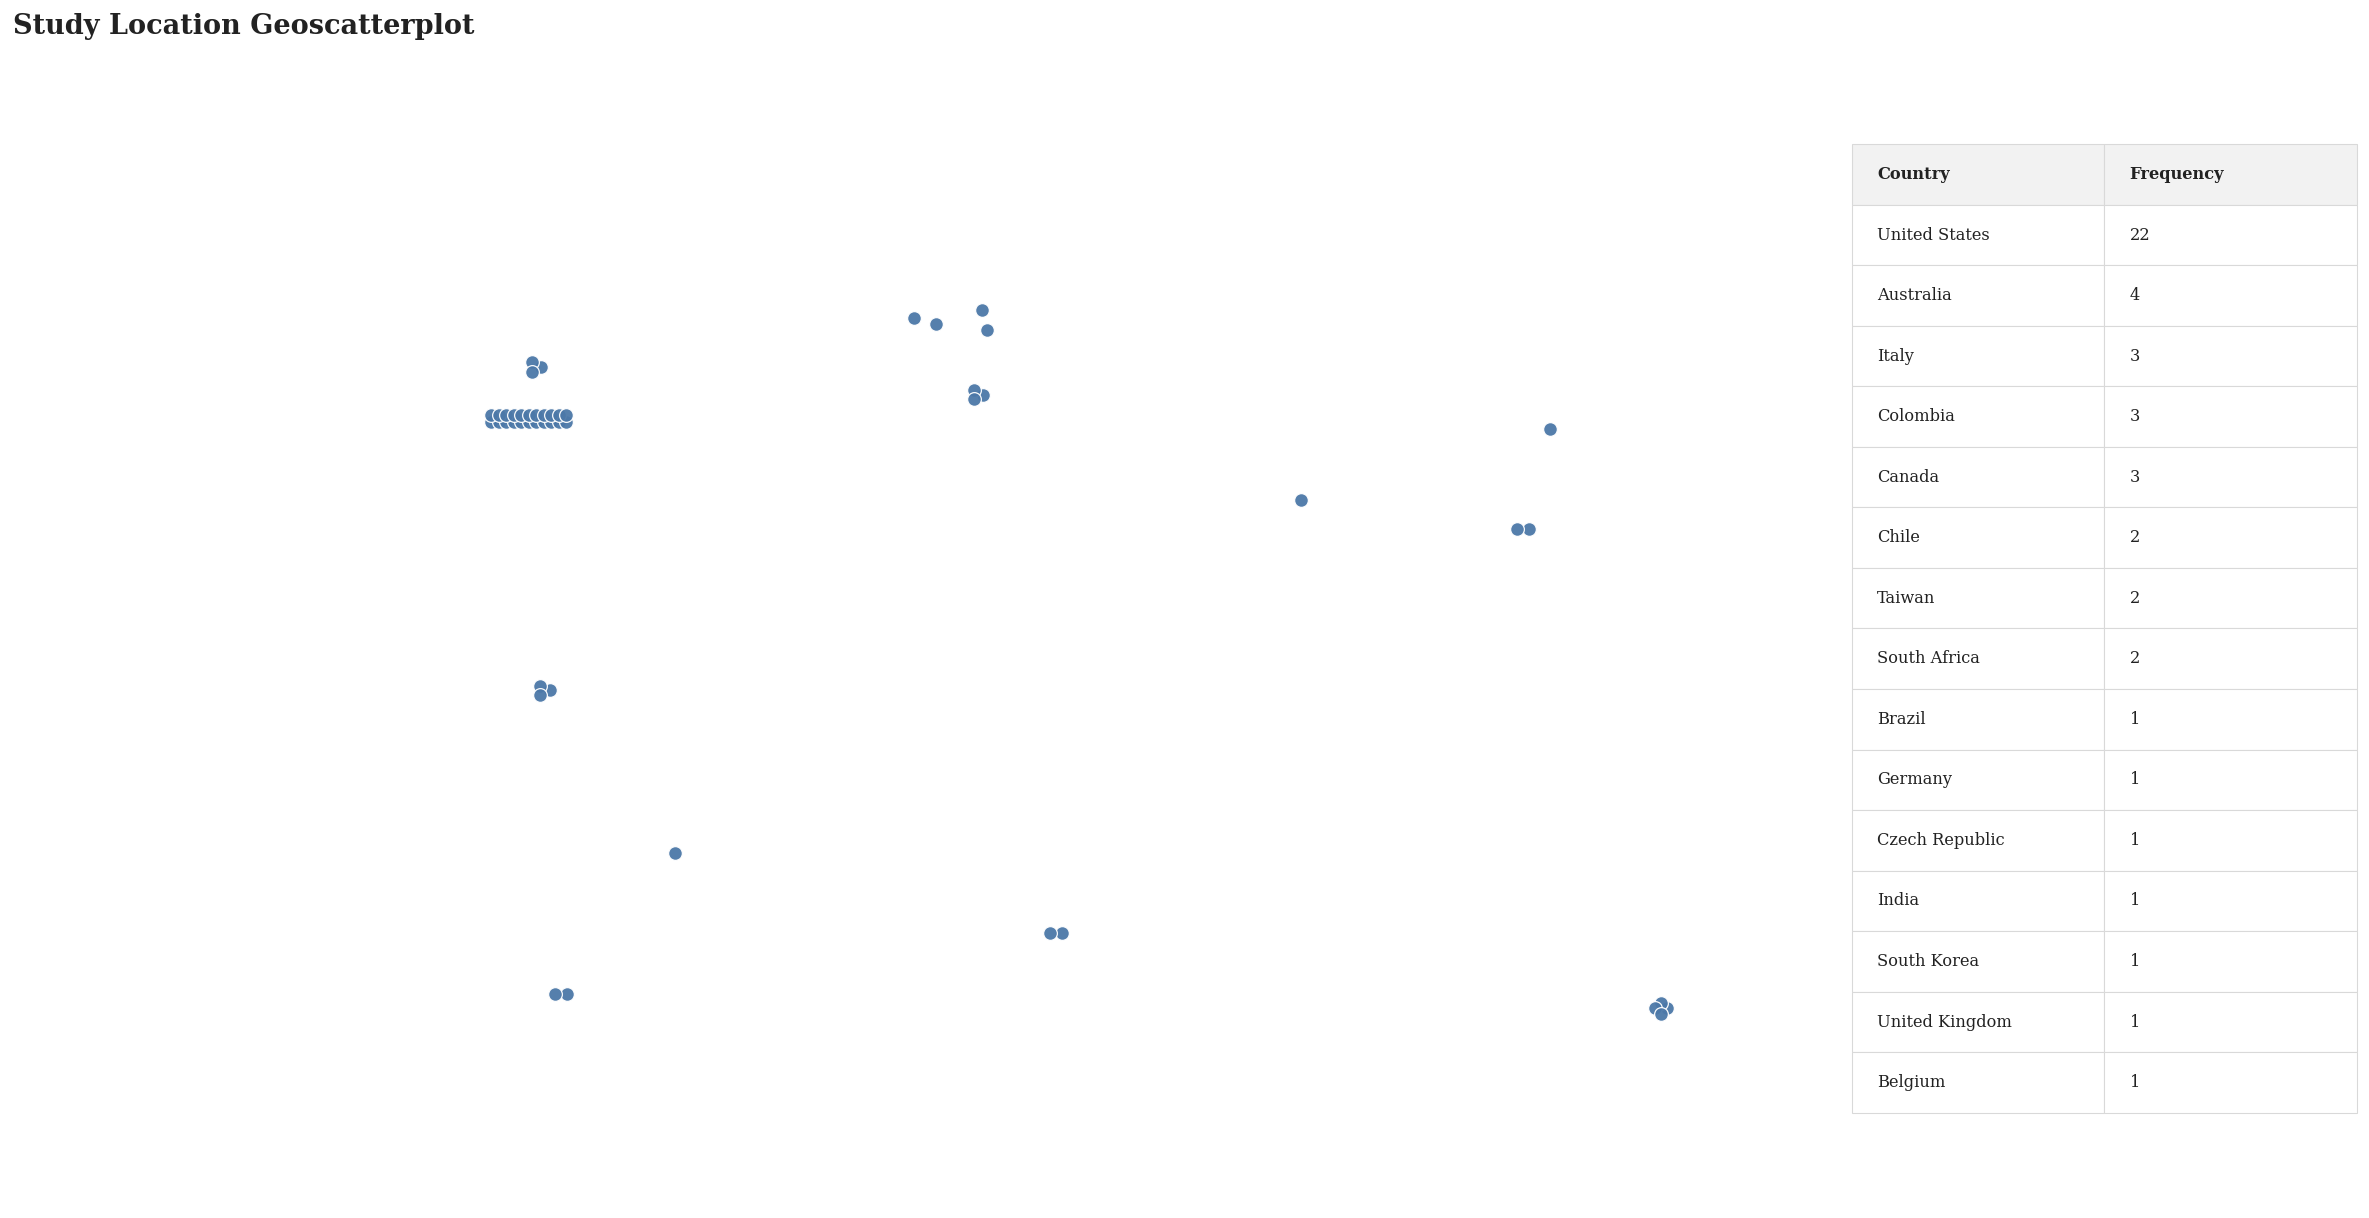

In [ ]:

# @title Study location geoscatterplot
country_frequency = pd.DataFrame({
    "Country": [
        "United States", "Australia", "Italy", "Colombia", "Canada", "Chile", "Taiwan", "South Africa",
        "Brazil", "Germany", "Czech Republic", "India", "South Korea", "United Kingdom", "Belgium"
    ],
    "Frequency": [22, 4, 3, 3, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1]
})

display(country_frequency)

capital_coordinates = {
    "United States": (38.9072, -77.0369),
    "Australia": (-35.2809, 149.1300),
    "Italy": (41.9028, 12.4964),
    "Colombia": (4.7110, -74.0721),
    "Canada": (45.4215, -75.6972),
    "Chile": (-33.4489, -70.6693),
    "Taiwan": (25.0330, 121.5654),
    "South Africa": (-25.7479, 28.2293),
    "Brazil": (-15.7939, -47.8828),
    "Germany": (52.5200, 13.4050),
    "Czech Republic": (50.0755, 14.4378),
    "India": (28.6139, 77.2090),
    "South Korea": (37.5665, 126.9780),
    "United Kingdom": (51.5074, -0.1278),
    "Belgium": (50.8503, 4.3517),
}

records = []
for _, row in country_frequency.iterrows():
    country = row["Country"]
    frequency = int(row["Frequency"])
    latitude, longitude = capital_coordinates[country]

    if country == "United States":
        points_per_row = 11
        num_rows = int(np.ceil(frequency / points_per_row))
        horizontal_spacing = 1.5
        vertical_spacing = 0.8
        offsets = []
        for i in range(frequency):
            row_index = i // points_per_row
            column_index = i % points_per_row
            delta_longitude = (column_index - (points_per_row - 1) / 2) * horizontal_spacing
            delta_latitude = (row_index - (num_rows - 1) / 2) * vertical_spacing
            offsets.append((delta_latitude, delta_longitude))
    elif frequency == 1:
        offsets = [(0.0, 0.0)]
    else:
        angles = np.linspace(0, 2 * np.pi, frequency, endpoint=False)
        longitude_radius = 1.2
        latitude_radius = 0.7
        offsets = [(latitude_radius * np.sin(angle), longitude_radius * np.cos(angle)) for angle in angles]

    for delta_latitude, delta_longitude in offsets:
        records.append({"Country": country, "Latitude": latitude + delta_latitude, "Longitude": longitude + delta_longitude})

points = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(18.5, 9.5), dpi=130)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

try:
    from mpl_toolkits.basemap import Basemap
    map_plot = Basemap(
        projection="cyl",
        llcrnrlon=-180,
        urcrnrlon=180,
        llcrnrlat=-60,
        urcrnrlat=85,
        resolution="c",
        ax=ax
    )
    map_plot.drawmapboundary(fill_color="white", linewidth=0)
    map_plot.fillcontinents(color="#F2F2F2", lake_color="white", zorder=0)
    map_plot.drawcoastlines(color="#C7C7C7", linewidth=0.5, zorder=1)
    map_plot.drawcountries(color="#D5D5D5", linewidth=0.4, zorder=1)
    x_values, y_values = map_plot(points["Longitude"].values, points["Latitude"].values)
    ax.scatter(x_values, y_values, s=58, color=JAMA_BLUE, edgecolor="white", linewidth=0.7, alpha=0.95, zorder=2)
except Exception:
    ax.scatter(points["Longitude"], points["Latitude"], s=58, color=JAMA_BLUE, edgecolor="white", linewidth=0.7, alpha=0.95)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)

ax.set_title("Study Location Geoscatterplot", loc="left", pad=10)
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.axis("off")

table = ax.table(
    cellText=country_frequency.values,
    colLabels=country_frequency.columns,
    cellLoc="left",
    colLoc="left",
    bbox=[1.02, 0.08, 0.28, 0.84]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D9D9D9")
    cell.set_linewidth(0.6)
    if row == 0:
        cell.set_facecolor("#F2F2F2")
        cell.set_text_props(weight="bold", color=JAMA_DARK)
    else:
        cell.set_facecolor("white")
        cell.set_text_props(color=JAMA_DARK)

plt.tight_layout()
plt.show()
